In [14]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [15]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import (
    PermutationLpModel,
    exclude_current_solution,
    exclude_largest_variable,
    exclude_current_solution_bigm,
)

Sortowanie po kącie wokół środka ciężkości. Traktowanie punktów jak punktów na tarczy zegara, ustawianie w kolejności wskazówek zegara, zaczynając od konkretnego kierunku odniesienia.

[Pozycje kandydatów xy, pozycje centrów grup xy, wagi grupy bez ostatniej (ALR), log-spready grup]

In [16]:
def sort_by_angle(points):
    """Sort 2D points counterclockwise around their centroid."""
    centroid = points.mean(axis=0)
    rel = points - centroid
    angles = np.arctan2(rel[:, 1], rel[:, 0])  # angle from +x axis, range (-pi, pi]
    order = np.argsort(angles)
    return points[order], order

## Generowanie scen, w których strategie wybierają różnych zwycięzców

Pipeline: **rejection sampling** scen (4 kandydatów + 4 grupy gaussowskie o **zmiennym,
izotropowym spreadzie**) → kodowanie do wektora cech długości **23** (8 pozycji kandydatów +
8 centrów grup, każde posortowane po kącie; 3 wagi w transformacie **ALR**; 4 **log-spready**
grup) → dopasowanie `gaussian_kde` → losowanie nowych scen z KDE z **weryfikacją** warunku.

Kluczowe decyzje projektowe (i dlaczego):

- **KDE traktujemy jako rozkład propozycji, nie jako prawdę o gęstości.** Weryfikacja na końcu
  gwarantuje poprawność; KDE ma tylko sprawić, by rejection był tani.
- **Wagi przez ALR** (`log(w_i / w_4)`) — `inv_alr` zawsze zwraca dodatnie wagi sumujące się do 1.
- **Spready przez log** (`σ_i > 0`): w cechach trzymamy `log(σ_i)`, dekodowanie przez `exp`,
  więc po KDE spready są zawsze dodatnie. Zmienny spread daje „ciasne, zwarte grupy” obok
  „rozlanych”, co jest dodatkowym źródłem rozbieżności Plurality vs Borda.
- **Wagi i spready permutujemy razem z centrami** (ten sam `order` z `sort_by_angle`), żeby
  każda waga/spread została przy swojej grupie.
- **Etykieta „różni zwycięzcy” jest losowa** względem parametrów (liczona na 200 wyborcach),
  więc krok weryfikacji świeżym losowaniem wyborców jest konieczny, nie opcjonalny.

Sortowanie kątowe usuwa permutacje grup/kandydatów, ale **nie** rotacji — to zwiększa rozrzut
cech (KDE potrzebuje wtedy więcej danych) i wprowadza nieciągłości, które jedno globalne pasmo
przegładza. Stąd dobór pasma przez LOO-CV i komórka diagnostyczna na końcu. Wymiar 23 jest
bardziej danożerny niż 19 — jeśli `reproduction rate`/`energy distance` się pogorszą, zbierz
więcej scen albo zmniejsz pasmo.

In [17]:
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree

K = 3  # number of voter groups (mixture components)
N_CANDIDATES = 3
N_VOTERS = 400
CANDIDATE_BOUNDS = (-9.0, 9.0)
SPREAD_BOUNDS = (0.3, 5)  # per-group isotropic std, log-uniform prior
DIRICHLET_ALPHA = 1.0  # flat prior over the group weights

strategies = [PluralityStrategy(), BordaCountStrategy()]
rng = np.random.default_rng(0)


def random_scene_params(rng):
    """Draw the *parameters* of a scene (not the individual voters)."""
    candidate_positions = rng.uniform(*CANDIDATE_BOUNDS, size=(N_CANDIDATES, 2))
    group_centers = rng.uniform(*CANDIDATE_BOUNDS, size=(K, 2))
    group_weights = rng.dirichlet(np.full(K, DIRICHLET_ALPHA))
    # log-uniform over SPREAD_BOUNDS so every scale is a priori equally likely.
    log_lo, log_hi = np.log(SPREAD_BOUNDS)
    group_spreads = np.exp(rng.uniform(log_lo, log_hi, size=K))
    return candidate_positions, group_centers, group_weights, group_spreads


def sample_voters(group_centers, group_weights, group_spreads, n_voters, rng):
    """Draw voter positions from the Gaussian mixture (per-group isotropic std)."""
    component = rng.choice(len(group_weights), size=n_voters, p=group_weights)
    return rng.normal(
        loc=group_centers[component],
        scale=group_spreads[component][:, None],
        size=(n_voters, 2),
    )


def winners_differ(candidate_positions, voter_positions):
    """True iff the strategies don't all pick the same strict (non-tied) winner.

    Fast path: works straight on the (n_voters, 2) / (n_candidates, 2) arrays and
    reuses each strategy's vectorised `tally_scores` on the shared distance matrix.
    Equivalent to building an Election, but skips creating one Candidate/Voter per
    position (the old per-call bottleneck) and the Tally/ElectionResult plumbing.
    """
    distances = np.linalg.norm(
        voter_positions[:, None, :] - candidate_positions[None, :, :], axis=2
    )
    winners = set()
    for strategy in strategies:
        scores = strategy.tally_scores(distances)  # (n_candidates,), column order
        top = scores.max()
        if np.count_nonzero(scores == top) > 1:  # tie -> no strict winner
            return False
        winners.add(int(scores.argmax()))  # column index == candidate id
    return len(winners) > 1

In [18]:
# Block order (must match between encode and the decode offsets below):
#   2*N_CANDIDATES : candidate (x, y), sorted CCW by angle around their centroid
#   2*K            : group center (x, y), sorted CCW by angle around their centroid
#   K-1            : group weights via ALR (the last is implied) -> free simplex
#   K              : per-group log-spread -> unconstrained; exp() on decode keeps sigma > 0
# Weights and spreads are permuted with the SAME order as the centers, so each
# stays attached to its group.


def alr(weights, eps=1e-6):
    """Additive log-ratio: simplex (n,) -> R^(n-1), last component as reference."""
    w = np.clip(weights, eps, None)
    return np.log(w[:-1] / w[-1])


def inv_alr(y):
    """Inverse ALR: R^(n-1) -> simplex (n,). Always strictly positive, sums to 1."""
    full = np.concatenate([y, [0.0]])
    e = np.exp(full - full.max())  # softmax, shifted for numerical stability
    return e / e.sum()


# Cumulative offsets of each block within a feature vector.
OFF_CENTERS = 2 * N_CANDIDATES
OFF_WEIGHTS = OFF_CENTERS + 2 * K
OFF_SPREADS = OFF_WEIGHTS + (K - 1)  # ALR drops one weight component
FEATURE_DIM = OFF_SPREADS + K


def encode_scene(candidate_positions, group_centers, group_weights, group_spreads):
    cand_sorted, _ = sort_by_angle(candidate_positions)
    centers_sorted, order = sort_by_angle(group_centers)
    return np.concatenate(
        [
            cand_sorted.ravel(),  # 2 * N_CANDIDATES
            centers_sorted.ravel(),  # 2 * K
            alr(group_weights[order]),  # K - 1
            np.log(group_spreads[order]),  # K
        ]
    )


def decode_features(feature):
    candidate_positions = feature[:OFF_CENTERS].reshape(N_CANDIDATES, 2)
    group_centers = feature[OFF_CENTERS:OFF_WEIGHTS].reshape(K, 2)
    group_weights = inv_alr(feature[OFF_WEIGHTS:OFF_SPREADS])
    group_spreads = np.exp(feature[OFF_SPREADS:])
    return candidate_positions, group_centers, group_weights, group_spreads


# round-trip sanity check: encode -> decode recovers weights/spreads (as multisets,
# since the angle sort permutes the group order).
_c, _g, _w, _s = random_scene_params(rng)
_feat = encode_scene(_c, _g, _w, _s)
_cand, _cen, _wt, _sp = decode_features(_feat)
print(
    f"feature dim: {len(_feat)} (FEATURE_DIM={FEATURE_DIM})",
    "| weights sum to 1:",
    np.isclose(_wt.sum(), 1.0),
    "| spreads recovered:",
    np.allclose(np.sort(_s), np.sort(_sp)),
)

feature dim: 17 (FEATURE_DIM=17) | weights sum to 1: True | spreads recovered: True


In [19]:
# Rejection sampling: collect scenes where the strategies disagree on the winner.
# We store only the feature vector of each accepted scene.


def collect_accepted_features(n_target, rng, report_every=5000):
    """Sample scenes until n_target of them produce DIFFERENT winners.

    Returns the (n_target, FEATURE_DIM) feature matrix and the raw acceptance
    rate - the baseline cost the KDE proposal has to beat.
    """
    features = []
    n_tried = 0
    while len(features) < n_target:
        n_tried += 1
        cand, centers, weights, spreads = random_scene_params(rng)
        voters = sample_voters(centers, weights, spreads, N_VOTERS, rng)
        if winners_differ(cand, voters):
            features.append(encode_scene(cand, centers, weights, spreads))
        if report_every and n_tried % report_every == 0:
            print(
                f"tried {n_tried}, accepted {len(features)} ({len(features) / n_tried:.1%})"
            )
    return np.array(features), len(features) / n_tried


train_features, acceptance_rate = collect_accepted_features(200000, rng)
print(f"baseline acceptance rate (strategies disagree): {acceptance_rate:.1%}")
print("feature matrix:", train_features.shape)

tried 5000, accepted 532 (10.6%)
tried 10000, accepted 1110 (11.1%)
tried 15000, accepted 1684 (11.2%)
tried 20000, accepted 2256 (11.3%)
tried 25000, accepted 2757 (11.0%)
tried 30000, accepted 3327 (11.1%)
tried 35000, accepted 3898 (11.1%)
tried 40000, accepted 4467 (11.2%)
tried 45000, accepted 5037 (11.2%)
tried 50000, accepted 5570 (11.1%)
tried 55000, accepted 6096 (11.1%)
tried 60000, accepted 6651 (11.1%)
tried 65000, accepted 7211 (11.1%)
tried 70000, accepted 7751 (11.1%)
tried 75000, accepted 8321 (11.1%)
tried 80000, accepted 8895 (11.1%)
tried 85000, accepted 9457 (11.1%)
tried 90000, accepted 10026 (11.1%)
tried 95000, accepted 10622 (11.2%)
tried 100000, accepted 11179 (11.2%)
tried 105000, accepted 11705 (11.1%)
tried 110000, accepted 12305 (11.2%)
tried 115000, accepted 12891 (11.2%)
tried 120000, accepted 13472 (11.2%)
tried 125000, accepted 14053 (11.2%)
tried 130000, accepted 14594 (11.2%)
tried 135000, accepted 15181 (11.2%)
tried 140000, accepted 15733 (11.2%)
tr

In [20]:
def loo_log_likelihood(features, bw_factor):
    """Leave-one-out mean log-likelihood of a gaussian_kde at a given bandwidth.

    Dropping point i just removes its own kernel, i.e. the K(0) self-term, from
    the all-points density - closed form, no refitting per point. Use it to pick
    bw_factor instead of trusting Scott/Silverman, which oversmooth in high
    dimension. Higher is better.
    """
    data = features.T  # gaussian_kde wants (n_dims, n_samples)
    d, n = data.shape
    kde = gaussian_kde(data, bw_method=bw_factor)
    _, logdet = np.linalg.slogdet(kde.covariance)
    self_term = np.exp(-0.5 * d * np.log(2 * np.pi) - 0.5 * logdet)  # K(0)
    dens = kde(data)
    loo = (n * dens - self_term) / (n - 1)
    return float(np.mean(np.log(np.clip(loo, 1e-300, None))))

In [21]:
# # Scan bandwidth factors around Scott's rule and keep the best by LOO-CV.
# scott = train_features.shape[0] ** (-1.0 / (train_features.shape[1] + 4))
# factors = scott * np.array([0.3, 0.5, 0.7, 1.0, 1.4])
# for f in factors:
#     print(
#         f"bw factor {f:.3f} (scott x{f / scott:.2f}): LOO loglik {loo_log_likelihood(train_features, f):.3f}"
#     )
# best_factor = float(
#     factors[int(np.argmax([loo_log_likelihood(train_features, f) for f in factors]))]
# )
# print(f"chosen bw factor: {best_factor:.3f}")

In [22]:
best_factor = 0.604

In [23]:
kde = gaussian_kde(train_features.T, bw_method=best_factor)

In [24]:
def generate_scene(kde, rng, verify=True, max_tries=50):
    """Sample a feature vector from the KDE, decode it, and (optionally) confirm
    the strategies really disagree on a fresh voter draw.

    Returns (candidate_positions, group_centers, group_weights, group_spreads,
    voters) or None if verification kept failing.
    """
    for _ in range(max_tries):
        feature = kde.resample(1, seed=rng).ravel()
        cand, centers, weights, spreads = decode_features(feature)
        voters = sample_voters(centers, weights, spreads, N_VOTERS, rng)
        if not verify or winners_differ(cand, voters):
            return cand, centers, weights, spreads, voters
    return None

winners: {'plurality': 0, 'borda': 2}
group spreads: [3.098 6.191 1.16 ]


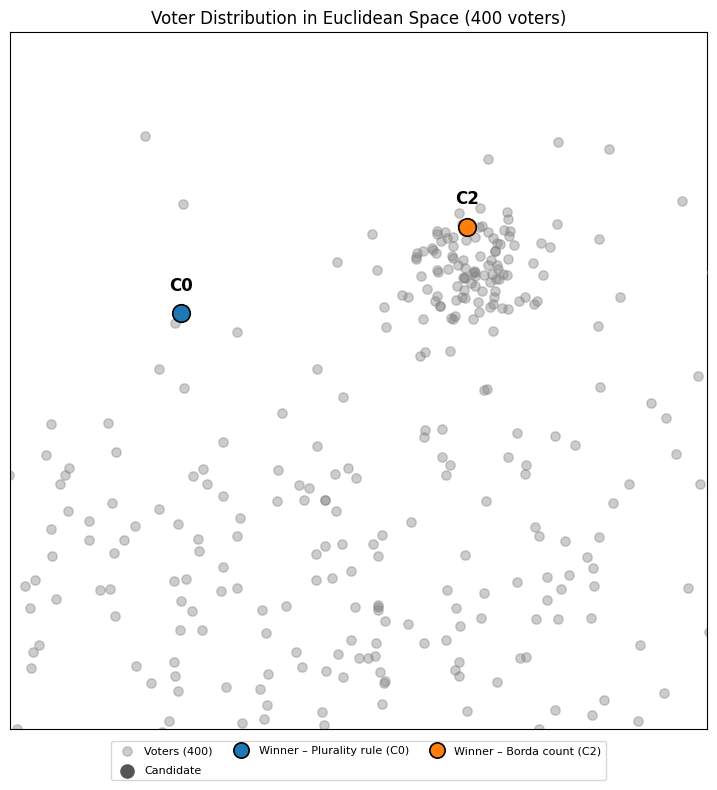

In [25]:
# One generated, verified scene.
scene = generate_scene(kde, rng)
cand, centers, weights, spreads, voters = scene

candidates = [Candidate(id=i, position=p) for i, p in enumerate(cand)]
voter_objs = [Voter(position=v) for v in voters]

result = Election(candidates, voter_objs).compare_strategies(strategies)

print("winners:", {key: c.id for key, c in result.winners().items()})
print("group spreads:", np.round(spreads, 3))
plot_results(result)

KDE reproduction rate: 21.5%   (baseline acceptance: 11.3%)
NN distance  gen->train: 7.175   train->train: 5.734
energy distance  train/train: 0.083   train/KDE: 0.284


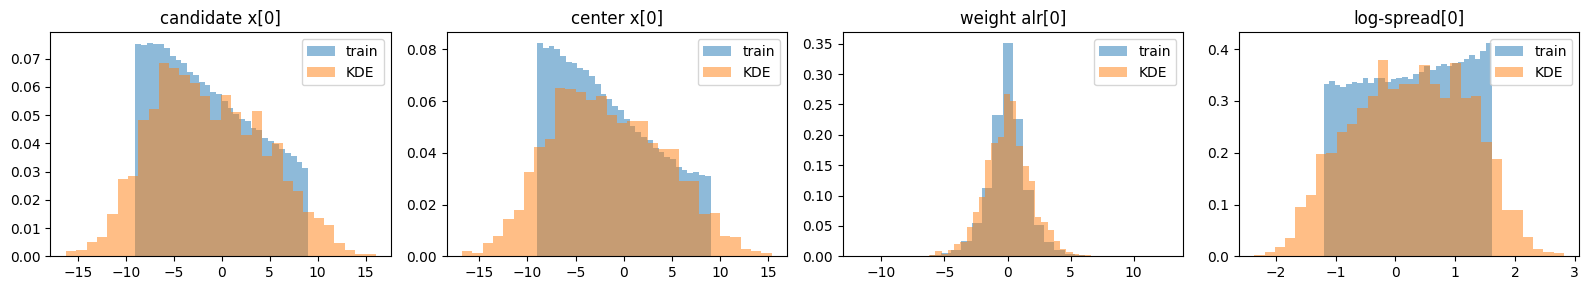

In [26]:
# Tests

# 1) Task metric: how often does a KDE sample actually disagree, on a FRESH
#    voter draw, vs the baseline rejection rate? This is the point of the whole
#    pipeline - it should be much higher than `acceptance_rate`.
def reproduction_rate(kde, rng, n=1000):
    ok = 0
    for _ in range(n):
        feature = kde.resample(1, seed=rng).ravel()
        cand, centers, weights, spreads = decode_features(feature)
        voters = sample_voters(centers, weights, spreads, N_VOTERS, rng)
        ok += winners_differ(cand, voters)
    return ok / n


repro = reproduction_rate(kde, rng)
print(
    f"KDE reproduction rate: {repro:.1%}   (baseline acceptance: {acceptance_rate:.1%})"
)

# 2) Memorisation: are KDE samples just jittered copies of training points?
#    generated->train NN distance should be comparable to train->train, not ~0.
gen_features = kde.resample(2000, seed=rng).T
tree = cKDTree(train_features)
d_gen = tree.query(gen_features, k=1)[0]
d_train = tree.query(train_features, k=2)[0][:, 1]  # nearest OTHER train point
print(
    f"NN distance  gen->train: {d_gen.mean():.3f}   train->train: {d_train.mean():.3f}"
)


# 3) Two-sample energy distance: held-out train split vs KDE samples. The
#    train/KDE value should be close to the train/train value.
def energy_distance(a, b, rng, m=400):
    a = a[rng.choice(len(a), min(m, len(a)), replace=False)]
    b = b[rng.choice(len(b), min(m, len(b)), replace=False)]

    def mean_dist(x, y):
        return np.linalg.norm(x[:, None, :] - y[None, :, :], axis=2).mean()

    return 2 * mean_dist(a, b) - mean_dist(a, a) - mean_dist(b, b)


half = len(train_features) // 2
ed_train = energy_distance(train_features[:half], train_features[half:], rng)
ed_gen = energy_distance(train_features[:half], gen_features, rng)
print(f"energy distance  train/train: {ed_train:.3f}   train/KDE: {ed_gen:.3f}")

# 4) Eyeball one marginal from each block (indices derived from the layout).
marginals = [
    (0, "candidate x[0]"),
    (OFF_CENTERS, "center x[0]"),
    (OFF_WEIGHTS, "weight alr[0]"),
    (OFF_SPREADS, "log-spread[0]"),
]
fig, axes = plt.subplots(1, len(marginals), figsize=(4 * len(marginals), 3))
for ax, (j, title) in zip(axes, marginals):
    ax.hist(train_features[:, j], bins=30, density=True, alpha=0.5, label="train")
    ax.hist(gen_features[:, j], bins=30, density=True, alpha=0.5, label="KDE")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()